In [10]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Dict

from model_ranking import (
    load_h5,
    find_selftraining_pred_paths,
    identify_transfer,
    get_output_paths,
)
from model_ranking import (
    get_ckpt_eval_scores
)
from pytorch3dunet.unet3d.config import load_config_direct

In [11]:
approach_mapping = {
    "DO": "feature_perturbation",
    "def": "default_selftraining",
    "cfd": "confidence_threshold",
    "F1": "direct_eval",
    "torchem": "supervised_torchem",
    "_SF_": "supervised",
    "ST": "supervised_training",
}

In [14]:
models: Dict[str, List[str]] = {
    "HtoE": [
        # "HtoE_def_Hm_model4",
        # "HtoE_def_Hm_model4_NG",
        "HtoE_def_Hm_model4_2",
        "HtoE_def_Hm_model_NA2",
        "HtoE_def_Hm_model_Res1",
        "HtoE_def_Hm_model_Unetr2",
        # "HtoE_def_Hm_model4_NG_2",
        # "HtoE_DOa02_th08_new_model1",
        # "HtoE_def_new_model1",
        # "HtoE_cfd09_new_model1",
        # "HtoE_F108_new_model2", 
        # "HtoE_SSdef_new_model1", 
        # "HtoE_SFtorchem_model5",
    ],
    "RtoE": [
        "RtoE_def_Rm_model4",
        "RtoE_def_Rm_model_NA2",
        "RtoE_def_Rm_model_Res1",
        "RtoE_def_Rm_model_Unetr2",
    ],
    "VtoE": [
        "VtoE_def_V_model2",
        "VtoE_def_V_model_NA2",
        "VtoE_def_V_model_NA2_2",
        "VtoE_def_V_model_Res1",
    ],
    "EtoH": [
        "EtoH_def_E_model5",
        "EtoH_def_E_model_NA2",
        "EtoH_def_E_model_Res1",
        "EtoH_def_E_model_Unetr2",
    ],
    "RtoH": [
        "RtoH_def_Rm_model4",
        "RtoH_def_Rm_model_NA2",
        "RtoH_def_Rm_model_Res1",
        "RtoH_def_Rm_model_Unetr2",
    ],
    "VtoH": [
        "VtoH_def_V_model2",
        "VtoH_def_V_model_NA2",
        "VtoH_def_V_model_Res1",
    ],
    "EtoR": [
        "EtoR_def_E_model5",
        "EtoR_def_E_model_NA2",
        "EtoR_def_E_model_Res1",
        "EtoR_def_E_model_Unetr2",
    ],
    "HtoR": [
        "HtoR_def_Hm_model4",
        "HtoR_def_Hm_model_NA2",
        "HtoR_def_Hm_model_NA2_2",
        "HtoR_def_Hm_model_Res1",
        "HtoR_def_Hm_model_Unetr2",
    ],
    "VtoR": [
        "VtoR_def_V_model2",
        "VtoR_def_V_model_NA2",
        "VtoR_def_V_model_Res1",
    ],
    "EtoV": [
        "EtoV_def_E_model5",
        "EtoV_def_E_model_NA2",
        "EtoV_def_E_model_Res1",
        "EtoV_def_E_model_Unetr2",
    ],
    "HtoV": [
        "HtoV_def_Hm_model4",
        "HtoV_def_Hm_model_NA2",
        "HtoV_def_Hm_model_Res1",
        "HtoV_def_Hm_model_Unetr2",
    ],
    "RtoV": [
        "RtoV_def_Rm_model4",
        "RtoV_def_Rm_model_NA2",
        "RtoV_def_Rm_model_Res1",
        "RtoV_def_Rm_model_Unetr2",
    ],
}

# models: Dict[str, List[str]] = {
#     "HtoE": [
#         "HtoE_DOa02_th08_new_model1",
#         "HtoE_def_new_model1",
#         "HtoE_cfd09_new_model1",
#         "HtoE_F108_new_model2", 
#         "HtoE_SSdef_new_model1", 
#         "HtoE_SFtorchem_model5",
#     ],
#     "VtoE": [
#         "VtoE_DOa02_th07_new_model1",
#         "VtoE_def_new_model1",
#         "VtoE_cfd09_new_model1",
#         "VtoE_F106_model1",
#         "VtoE_SFtorchem_new_model1",
#     ],
#     "HtoR": [
#         "HtoR_cfd09_new_model1",
#         "HtoR_def_new_model1",
#         "HtoR_DOa02_th08_new_model1",
#         "HtoR_F108_new_model1",
#         "HtoR_SFtorchem_new_model1",
#     ],
#     "RtoH": [
#         "RtoH_cfd09_new_model1",
#         "RtoH_def_new_model1",
#         "RtoH_DOa02_th08_new_model1",
#         "RtoH_F107_new_model1",
#         "RtoH_SFtorchem_new_model1",
#     ],
#     "EtoH": [
#         "EtoH_cfd09_new_model1",
#         "EtoH_def_new_model1",
#         "EtoH_DOa02_th08_new_model1",
#         "EtoH_F1075_new_model1",
#         "EtoH_SFtorchem_new_model1",
#     ],
#     "EtoR": [
#         "EtoR_cfd09_new_model1",
#         "EtoR_def_new_model1",
#         "EtoR_DOa02_th08_new_model1",
#         "EtoR_F1075_new_model1",
#         "EtoR_SFtorchem_new_model1",
#     ],
#     "EtoV": [
#         "EtoV_cfd09_new_model1",
#         "EtoV_def_new_model1",
#         "EtoV_def_new_model2",
#         "EtoV_DOa02_th08_new_model1",
#         "EtoV_F107_new_model1",
#         "EtoV_SFtorchem_new_model1",
#     ],
#     "HtoV": [
#         "HtoV_def_new_model1",
#     ],
#     "RtoE": [
#         "RtoE_def_new_model1",
#     ],
#     "RtoV": [
#         "RtoV_def_new_model1",
#     ],
#     "VtoH": [
#         "VtoH_def_new_model1",
#     ],
#     "VtoR": [
#         "VtoR_def_new_model1",
#     ],

# }

Transfer: HtoE


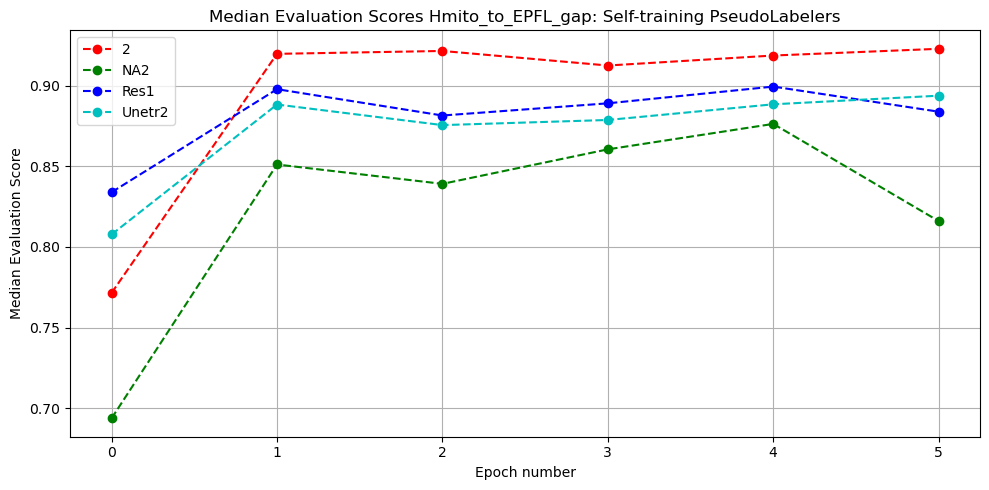

Transfer: RtoE


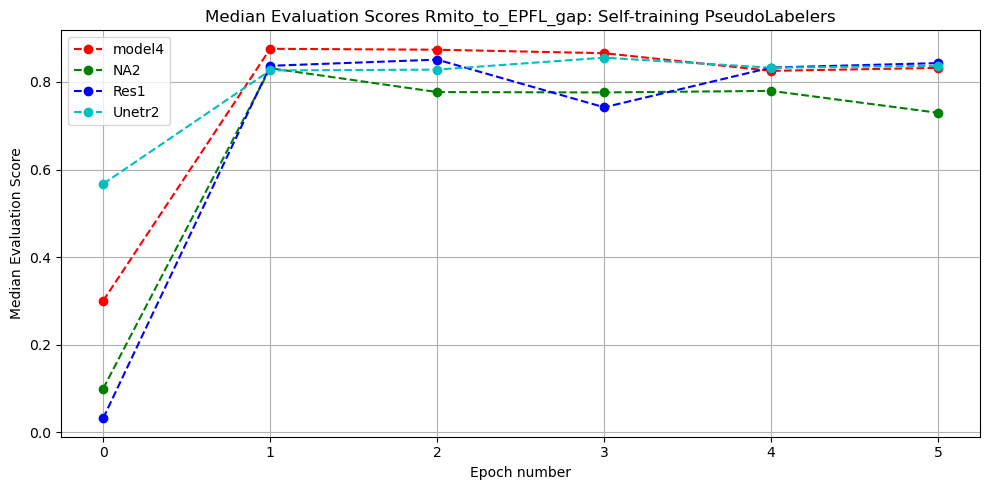

Transfer: VtoE


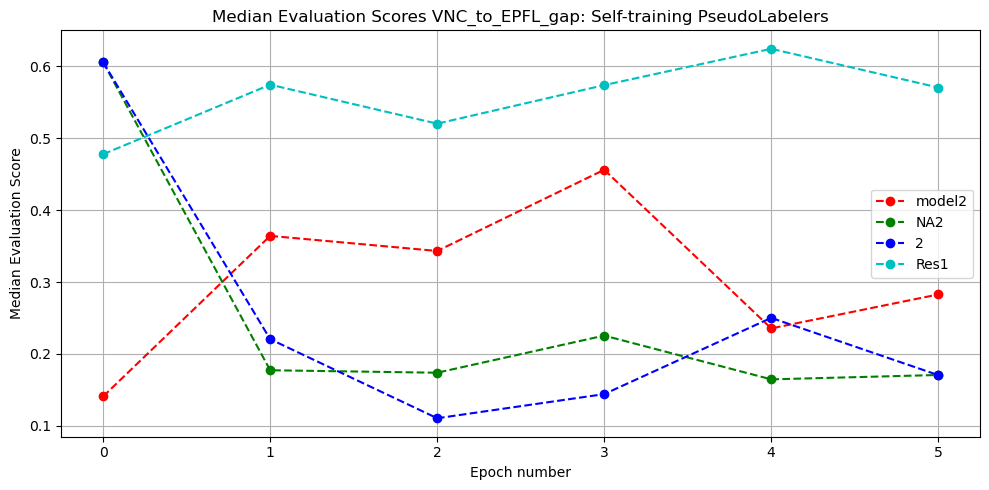

Transfer: EtoH


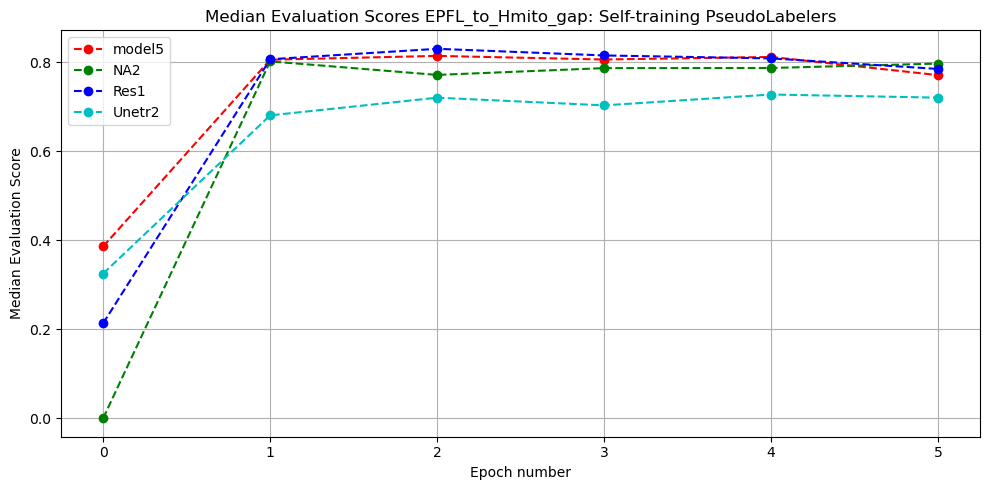

Transfer: RtoH


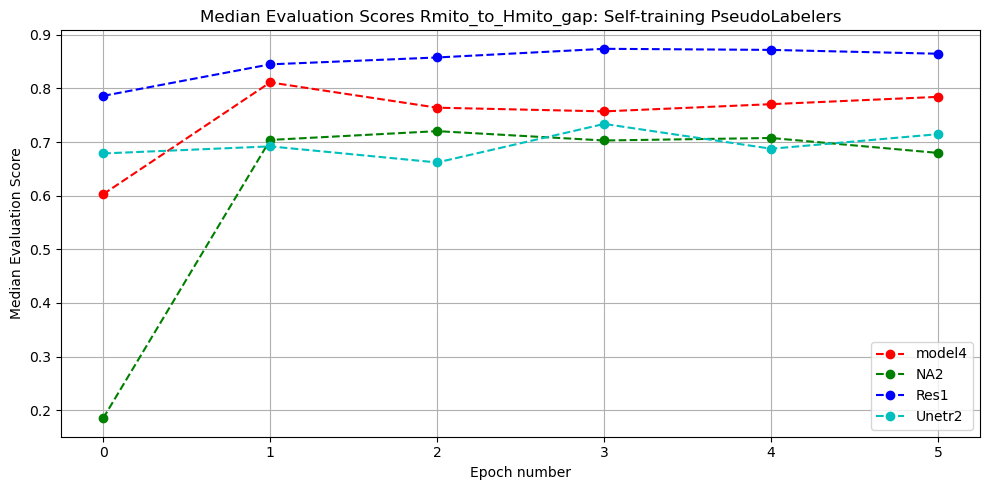

Transfer: VtoH


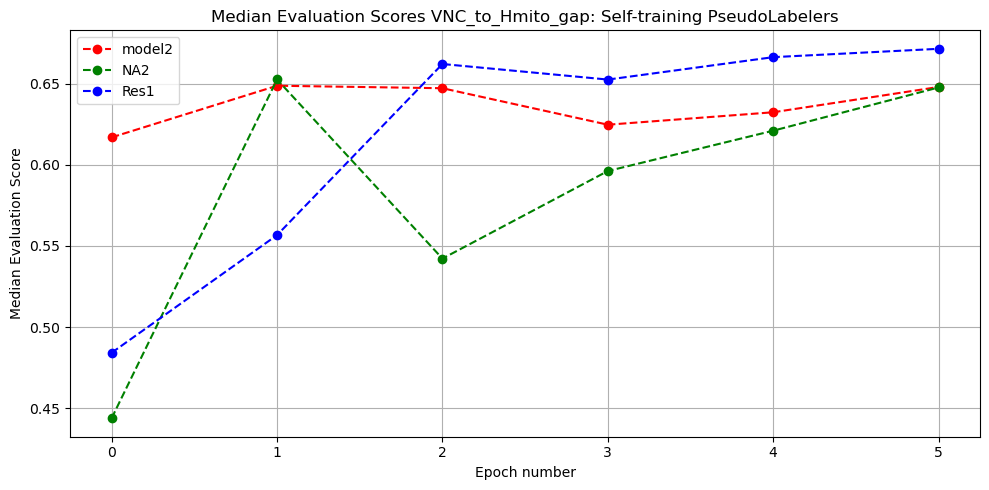

Transfer: EtoR


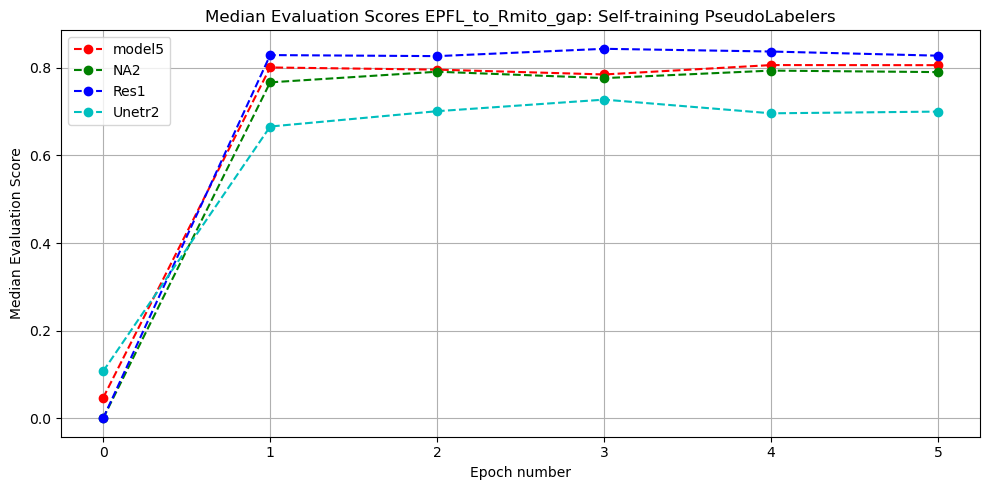

Transfer: HtoR


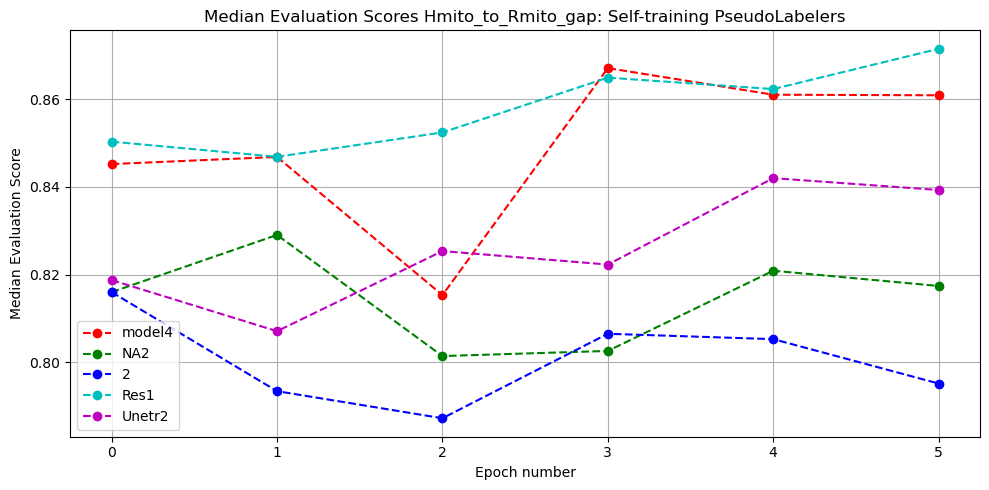

Transfer: VtoR


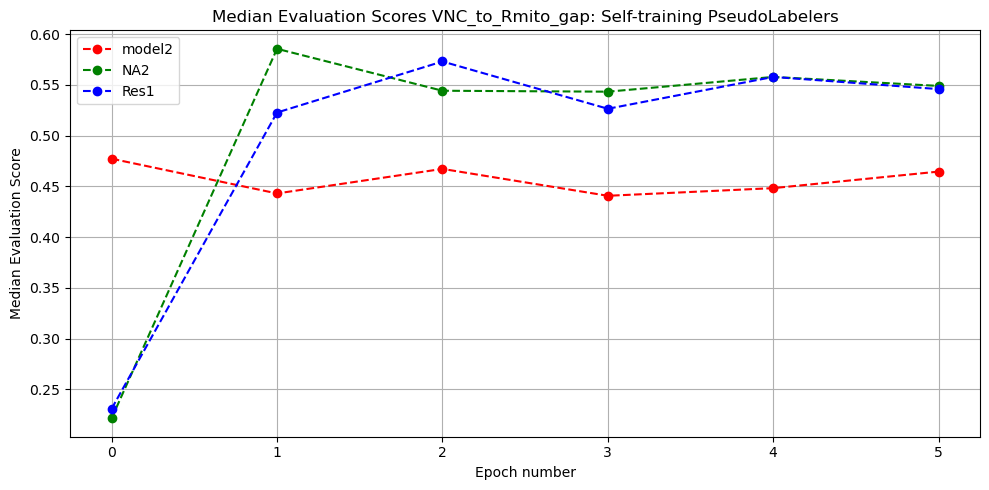

Transfer: EtoV


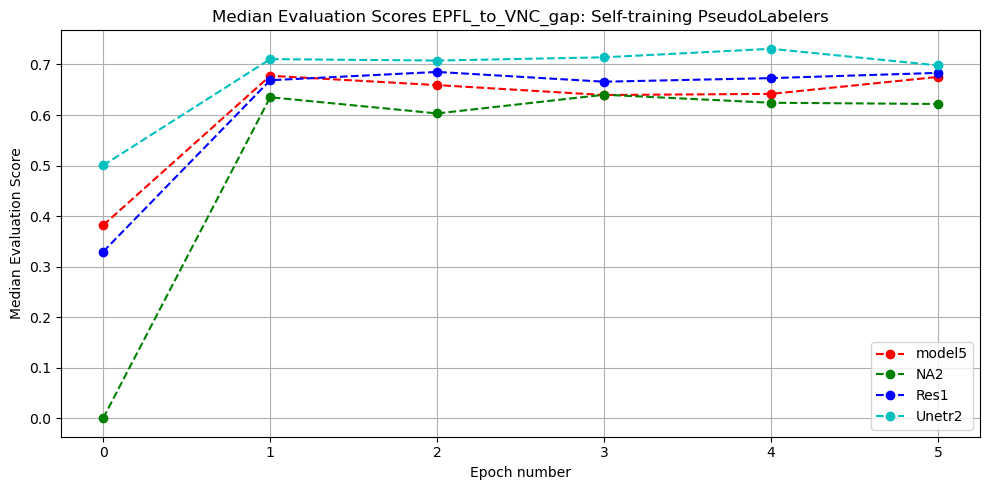

Transfer: HtoV


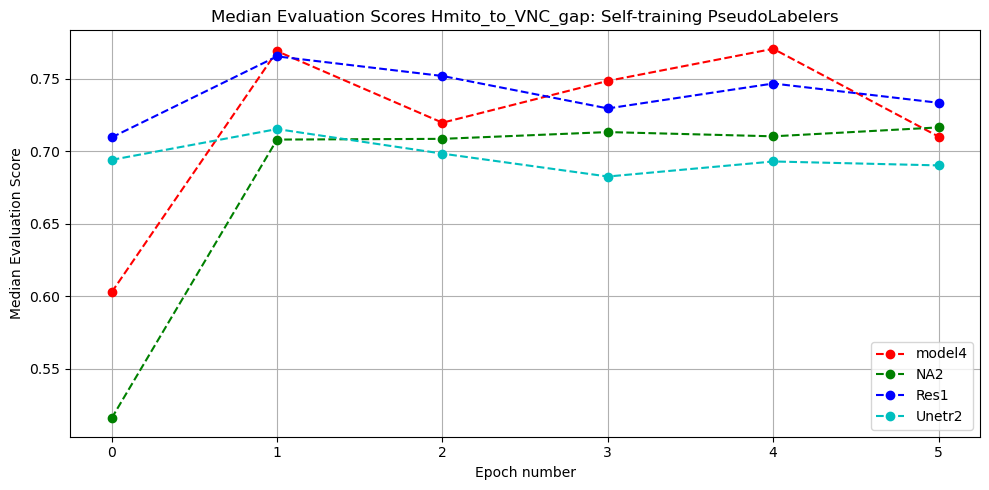

Transfer: RtoV


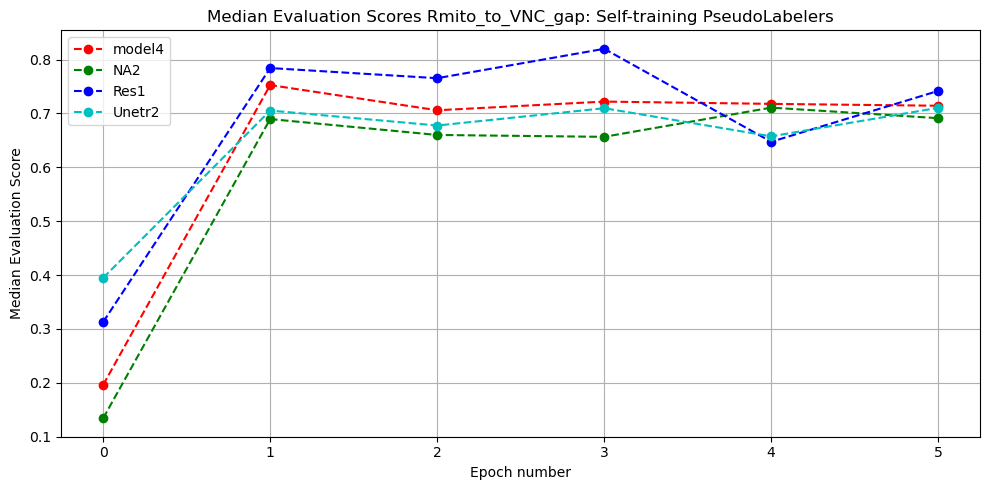

In [15]:

colours = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray']
best_epoch_per_transfer: Dict[str, Dict[str, int]] = {}
for transfer, model_list in models.items():
    print(f"Transfer: {transfer}")
    _ = plt.figure(figsize=(10,5))
    best_epochs_per_model: Dict[str, int] = {}
    for i, model_name in enumerate(model_list):
        if "SS" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/SemiSupervised-Finetuning/Mitochondria")
        elif "SF" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-Finetuning/Mitochondria")
        elif "ST" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-training/Mitochondria")
        else:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria")
        approach = None
        #label = None
        label = model_name.split("_")[-1]
        for key in approach_mapping:
            if key in model_name:
                approach = approach_mapping[key]
        #         if key == "DO":
        #             label = "_".join(model_name.split("_")[1:3])
        #         else:
        #             label = model_name.split("_")[1]
        #         break

        assert approach is not None, f"Approach not found for model: {model_name}"
        assert label is not None, f"Label not found for model: {model_name}"

        pred_path = find_selftraining_pred_paths([model_name], approach=approach, base_path=base_path)[0]

        yaml_paths = list((pred_path.parent.parent / "checkpoints" / model_name).glob("*.yaml"))
        
        assert len(yaml_paths) == 1, f"Expected one YAML file for {model_name}, found {len(yaml_paths)}"
        yaml_path = yaml_paths[0]
        
        base_model_name = Path(load_config_direct(yaml_path)[0]["training"]["model_cfg"]["source_checkpoint"]).parent.stem
        
        transfer = identify_transfer(pred_path)
        assert transfer is not None, f"Transfer section not found in path: {pred_path}"
        target = transfer.split("_")[2]

        paths = get_output_paths(
            transfer.split("_")[0], 
            transfer.split("_")[2], 
            {"none": []}, 
            [None], 
            base_model_name, 
            output="predictions", 
            result_folder ="P_full", 
            approach="consistency",
            base_dir_path="/scratch/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(paths) == 1, f"Expected one path for {transfer} {base_model_name}, found {len(paths)}"
        direct_pred_path = list(Path(paths[0]).glob("*.h5"))
        # remove metric_summary_paths
        direct_pred_path = [p for p in direct_pred_path if "metric_summary" not in str(p)]
        assert len(direct_pred_path) == 1, f"Expected one direct prediction path for {transfer} {base_model_name}, found {len(direct_pred_path)}"

        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")
        eval_direct_median = np.median(eval_score_direct, axis=0)

        if "_SF_" in model_name:
            epoch_ids = list(range(1, 21, 2))
            #epoch_ids = list(range(1, 5, 2))
            #epoch_ids = list(range(2, 6, 2))
        else:
            #epoch_ids = list(range(2, 22, 2))
            #epoch_ids = list(range(1, 11, 1))
            epoch_ids = list(range(1, 6, 1))
            #epoch_ids = list(range(2, 6, 2))


        mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(pred_path, epoch_ids)
        median_eval_scores.insert(0, eval_direct_median[1])
        #epochs = list(range(0, 22, 2))
        # epochs = list(range(0, 11, 1))
        epochs = list(range(0, 6, 1))
        #epochs = list(range(0, 6, 2))
        #epochs = epoch_ids.copy()
        #epochs.insert(0,0)  # Include the direct evaluation at epoch 0

        best_epoch_id = median_eval_scores.index(max(median_eval_scores))
        best_epochs_per_model[model_name] = best_epoch_id
        
        _ = plt.plot(epochs, median_eval_scores, marker='o', linestyle='--', color=colours[i], label=label)
    
    best_epoch_per_transfer[transfer] = best_epochs_per_model

    _ =plt.title(f'Median Evaluation Scores {transfer}: Self-training PseudoLabelers')
    _ =plt.xlabel('Epoch number')
    _ =plt.ylabel(f'Median Evaluation Score')
    _ = plt.xticks(epochs)
    _ = plt.legend()
    plt.grid()
    plt.tight_layout()
        #plt.savefig("mean_eval_scores_over_checkpoints.png")
    plt.show()


In [16]:
best_epoch_per_transfer

{'Hmito_to_EPFL_gap': {'HtoE_def_Hm_model4_2': 5,
  'HtoE_def_Hm_model_NA2': 4,
  'HtoE_def_Hm_model_Res1': 4,
  'HtoE_def_Hm_model_Unetr2': 5},
 'Rmito_to_EPFL_gap': {'RtoE_def_Rm_model4': 1,
  'RtoE_def_Rm_model_NA2': 1,
  'RtoE_def_Rm_model_Res1': 2,
  'RtoE_def_Rm_model_Unetr2': 3},
 'VNC_to_EPFL_gap': {'VtoE_def_V_model2': 3,
  'VtoE_def_V_model_NA2': 0,
  'VtoE_def_V_model_NA2_2': 0,
  'VtoE_def_V_model_Res1': 4},
 'EPFL_to_Hmito_gap': {'EtoH_def_E_model5': 2,
  'EtoH_def_E_model_NA2': 1,
  'EtoH_def_E_model_Res1': 2,
  'EtoH_def_E_model_Unetr2': 4},
 'Rmito_to_Hmito_gap': {'RtoH_def_Rm_model4': 1,
  'RtoH_def_Rm_model_NA2': 2,
  'RtoH_def_Rm_model_Res1': 3,
  'RtoH_def_Rm_model_Unetr2': 3},
 'VNC_to_Hmito_gap': {'VtoH_def_V_model2': 1,
  'VtoH_def_V_model_NA2': 1,
  'VtoH_def_V_model_Res1': 5},
 'EPFL_to_Rmito_gap': {'EtoR_def_E_model5': 4,
  'EtoR_def_E_model_NA2': 4,
  'EtoR_def_E_model_Res1': 3,
  'EtoR_def_E_model_Unetr2': 3},
 'Hmito_to_Rmito_gap': {'HtoR_def_Hm_model4': 3,

In [17]:
save_path = Path("/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/default_self_training_best_epochs")
save_path.mkdir(parents=True, exist_ok=True)
save_path = save_path / "best_epochs_per_transfer.json"
import json
with open(save_path, "w") as f:
    json.dump(best_epoch_per_transfer, f, indent=4)
print(f"Best epochs per transfer saved to {save_path}")

Best epochs per transfer saved to /g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/default_self_training_best_epochs/best_epochs_per_transfer.json


In [1]:
import torch
path = "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Rmito_to_VNC_gap/default_selftraining/checkpoints/RtoV_def_Rm_model_Res1/best.pt"
path2 = "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Rmito_to_VNC_gap/default_selftraining/checkpoints/RtoV_def_Rm_model_Res1/epoch-1.pt"
state_dict = torch.load(path, map_location='cpu')
state_dict2 = torch.load(path2, map_location='cpu')

/tmp/ipykernel_3678455/1995312380.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_location='cpu')


INFO: P [MainThread] 2025-08-15 14:00:53,595 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/tmp/ipykernel_3678455/1995312380.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via 

In [8]:
state_dict2['best_epoch']

0

In [2]:
state_dict.keys()

dict_keys(['iteration', 'epoch', 'best_epoch', 'best_metric', 'current_metric', 'model_state', 'optimizer_state', 'init', 'train_time', 'timestamp', 'teacher_state', 'scaler_state', 'scheduler_state'])

In [5]:
models_equal = torch.equal(torch.stack([v for v in state_dict['model_state'].values() if isinstance(v, torch.Tensor)]), 
                          torch.stack([v for v in state_dict2['model_state'].values() if isinstance(v, torch.Tensor)]))
print(f"Model states are equal: {models_equal}")

# Alternative approach - check each parameter individually
all_equal = True
for key in state_dict['model_state'].keys():
    if not torch.equal(state_dict['model_state'][key], state_dict2['model_state'][key]):
        all_equal = False
        print(f"Difference found in parameter: {key}")
        break

print(f"All parameters equal: {all_equal}")

RuntimeError: stack expects each tensor to be equal size, but got [64, 1, 1, 1] at entry 0 and [64] at entry 1

In [6]:
# Check if the model states are equal
all_equal = True
for key in state_dict['model_state'].keys():
    if not torch.equal(state_dict['model_state'][key], state_dict2['model_state'][key]):
        all_equal = False
        print(f"Difference found in parameter: {key}")
        print(f"  Shape in state_dict: {state_dict['model_state'][key].shape}")
        print(f"  Shape in state_dict2: {state_dict2['model_state'][key].shape}")
        print(f"  Max absolute difference: {torch.max(torch.abs(state_dict['model_state'][key] - state_dict2['model_state'][key]))}")
        break

print(f"state_dict['model_state'] == state_dict2['model_state']: {all_equal}")

# Also check if they have the same keys
keys_equal = set(state_dict['model_state'].keys()) == set(state_dict2['model_state'].keys())
print(f"Same parameter keys: {keys_equal}")
print(f"Number of parameters in state_dict: {len(state_dict['model_state'])}")
print(f"Number of parameters in state_dict2: {len(state_dict2['model_state'])}")

Difference found in parameter: encoders.0.basic_module.conv1.weight
  Shape in state_dict: torch.Size([64, 1, 1, 1])
  Shape in state_dict2: torch.Size([64, 1, 1, 1])
  Max absolute difference: 0.0007376670837402344
state_dict['model_state'] == state_dict2['model_state']: False
Same parameter keys: True
Number of parameters in state_dict: 124
Number of parameters in state_dict2: 124
